# Лабораторная работа #3 #
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

### Исходные данные  ####
Исследуемая функция: $ f(x) = x^2 - 2x + e^{-x} $;
Промежуток: $ [1, 1.5] $

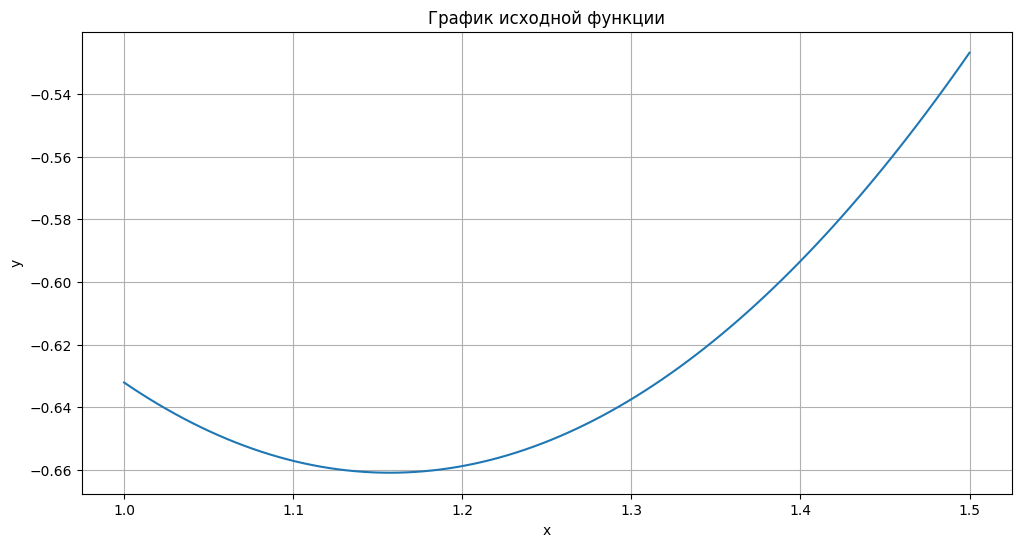

In [6]:
import math
# Импорт необходимых зависимостей
from typing import Any
import matplotlib.pyplot as plt
import numpy as np

# Исходная функция
def f(arg: float | np.ndarray[tuple[Any, ...], np.dtype[np.float64]]) -> float:
    return arg ** 2 - 2 * arg + np.exp(-arg)

# График исходной функции
a = 1
b = 1.5
epsilon = 0.0001
x = np.linspace(a, b, 100)

plt.figure(figsize=(12, 6))
plt.plot(x, f(x))
plt.xlabel('x')
plt.ylabel('y')
plt.title('График исходной функции')
plt.grid(True)
plt.show()

## Метод квадратичной аппроксимации



### I. Теоретические основы
Функция, принимающая минимальное значение во внутренней точке интервала, должна быть, по крайней мере, квадратичной. Если же функция линейная, то ее оптимальное значение может достигаться только в одной из двух граничных точек интервала.

При реализации метода оценивания с использованием квадратичной аппроксимации предполагается, что в ограниченном интервале можно аппроксимировать функцию квадратичным полиномом, а затем использовать построенную аппроксимационную схему для оценивания координаты точки истинного минимума функции.

### II. Алгоритм
Шаг 1. Задать начальную (первую) точку $x_1$, величину шага по оси х - $\triangle x > 0$, $\varepsilon_1$ и $\varepsilon_2$ - малые положительные значения, характеризующие точность

Шаг 2. Вычислить вторую точку: $x_2$ = $x_1$ + $\triangle x$

Шаг 3. Вычислить значения функции в точках $f(x_1)$ и $f(x_2)$.

Шаг 4. Сравнить точки $f(x_1)$ и $f(x_2)$:
a) если $f(x_1) > f(x_2)$, положить $x_3 = x_1 + 2\Delta x$ (рис. a);
б) если $f(x_1) \leq f(x_2)$, положить $x_3 = x_1 - \Delta x$ (рис. б).

![image.png](assets/alg-step-4.png)

Шаг 5. Вычислить $f(x_3) = f_3$.

Шаг 6. Найти $F_{\text{min}} = \min\{f_1, f_2, f_3\}$, $x_{\text{min}} = x_i$.

Шаг 7. По точкам $x_1, x_2, x_3$ вычислить точку минимума $\bar{x}$ квадратичного интерполяционного полинома:

$$\bar{x} = \frac{1}{2} \left( \frac{(x_2^2 - x_3^2)f_1 + (x_3^2 - x_1^2)f_2 + (x_1^2 - x_2^2)f_3}{(x_2 - x_3)f_1 + (x_3 - x_1)f_2 + (x_1 - x_2)f_3} \right)$$

и величину функции $f(\bar{x})$.

Если знаменатель в формуле для $\bar{x}$ на некоторой итерации обращается в ноль, то результатом итерации является прямая. В этом случае рекомендуется обозначить $x_1 = x_{\text{min}}$ и перейти к шагу 2.

Шаг 8. Проверить выполнение условий окончания расчета:

$$\left| \frac{F_{\text{min}} - f(\bar{x})}{f(\bar{x})} \right| < \varepsilon_1, \quad \left| \frac{x_{\text{min}} - \bar{x}}{\bar{x}} \right| < \varepsilon_2.$$

а) если оба условия выполняются, закончить поиск $x^* = \bar{x}$;
б) если хотя бы одно из условий не выполняется и $\bar{x} \in [x_1; x_3]$, (Точки должны быть предварительно отсортированы по возрастанию) выбрать наименьшую точку ($x_{\text{min}}$ или $\bar{x}$) (если $f(x_{\text{min}}) < f(\bar{x})$, то $x_{\text{min}}$
наименьшая, иначе $\bar{x}$ наименьшая) и две точки по обе стороны от нее. Обозначить эти точки в обычном порядке и перейти к шагу 6;
в) если хотя бы одно из условий не выполняется и $\bar{x} \notin [x_1; x_3]$, то положить точку $x_1 = \bar{x}$ и перейти к шагу 2.
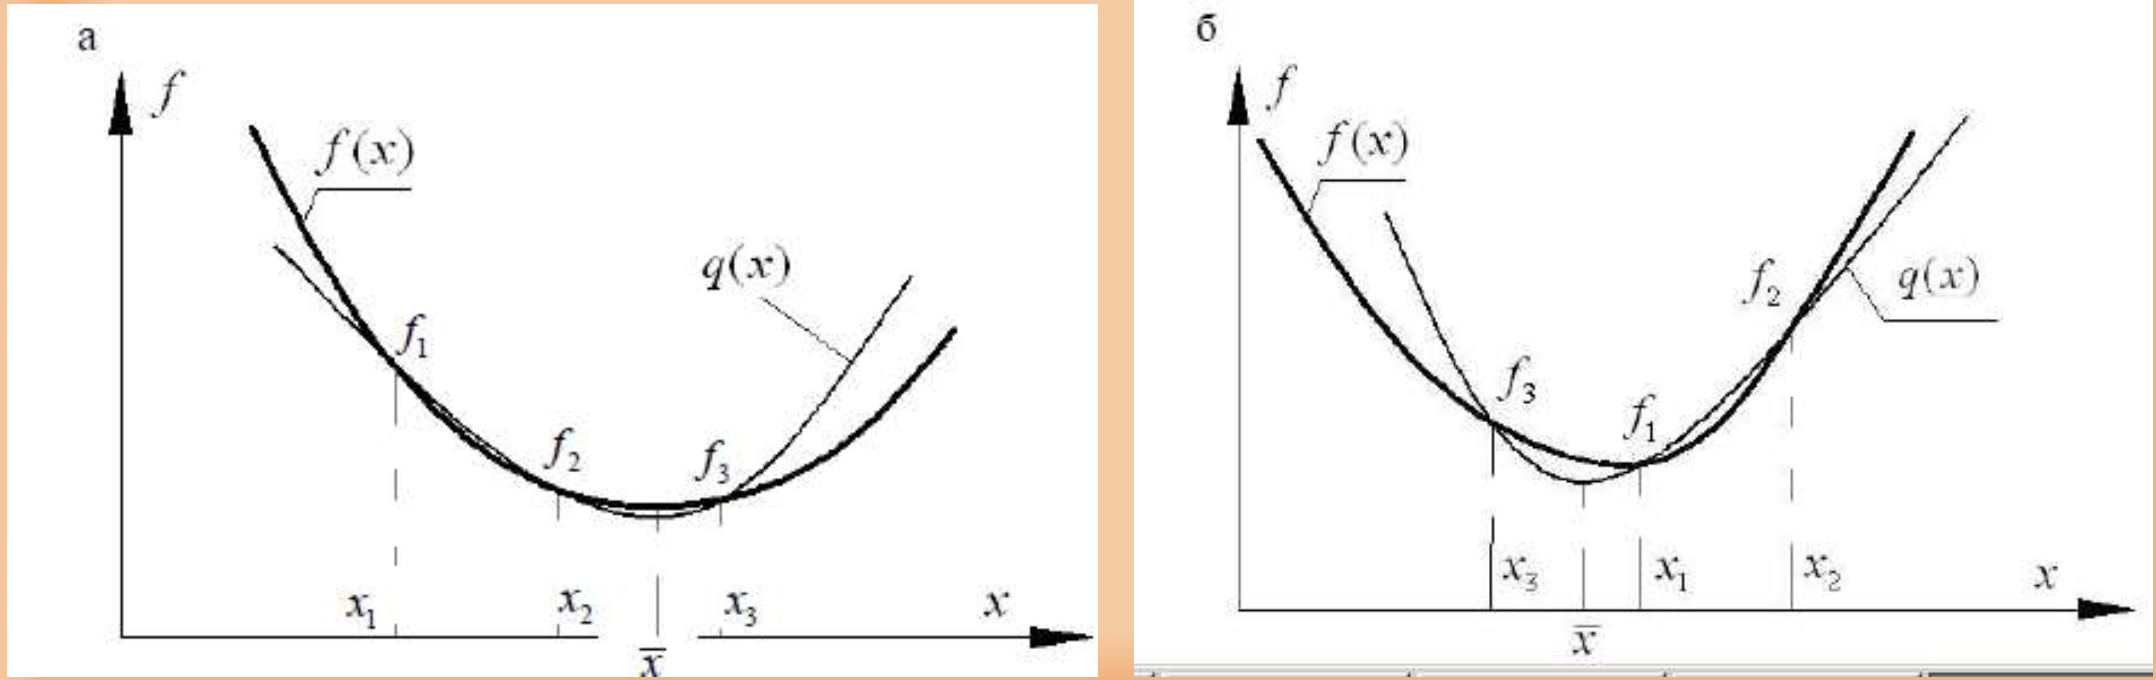

### III. Реализация

In [13]:
from typing import Callable

def quadratic_approximation(fn: Callable[[float], float], x1, delta_x, eps1=0.0001, eps2=None, max_iter=100):
    """
    Метод квадратичной аппроксимации для поиска минимума функции

    Параметры:
    fn - функция
    x1 - начальная точка
    delta_x - начальный шаг по оси x (>0)
    eps1 - точность по функции (по умолчанию 0.0001)
    eps2 - точность по аргументу (если None, то равна eps1)
    max_iter - максимум итераций

    Возвращает:
    x_min - найденный минимум
    history - история приближений
    """

    if eps2 is None:
        eps2 = eps1

    # Шаг 1: заданы x1, delta_x, eps1, eps2

    # Шаг 2: вычисляем вторую точку
    x2 = x1 + delta_x

    # Шаг 3: вычисляем значения функции
    f1 = fn(x1)
    f2 = fn(x2)

    # Шаг 4: определяем третью точку
    if f1 > f2:  # случай а) на рисунке - убывание
        x3 = x1 + 2 * delta_x
        print(f"Случай а) f1 > f2: движение вправо")
    else:  # случай б) f1 <= f2 - возрастание или плато
        x3 = x1 - delta_x
        print(f"Случай б) f1 <= f2: движение влево")

    # Шаг 5: вычисляем f3
    f3 = fn(x3)

    # Сортируем точки по возрастанию x (для интервала [x1; x3])
    points = sorted([(x1, f1), (x2, f2), (x3, f3)])
    x1, f1 = points[0]
    x2, f2 = points[1]
    x3, f3 = points[2]

    print(f"Начальные точки после сортировки:")
    print(f"x1={x1:.6f} (f={f1:.6f}), x2={x2:.6f} (f={f2:.6f}), x3={x3:.6f} (f={f3:.6f})")

    x_bar = None
    history = [(x1, f1), (x2, f2), (x3, f3)]

    for iteration in range(max_iter):
        print(f"\n--- Итерация {iteration + 1} ---")
        print(f"Точки: x1={x1:.6f} (f={f1:.6f}), x2={x2:.6f} (f={f2:.6f}), x3={x3:.6f} (f={f3:.6f})")

        # Шаг 6: Находим текущий минимум
        if f1 <= f2 and f1 <= f3:
            f_min, x_min = f1, x1
        elif f2 <= f1 and f2 <= f3:
            f_min, x_min = f2, x2
        else:
            f_min, x_min = f3, x3

        print(f"Текущий минимум: x_min={x_min:.6f}, F_min={f_min:.6f}")

        # Шаг 7: Вычисляем точку минимума параболы
        numerator = (x2**2 - x3**2) * f1 + (x3**2 - x1**2) * f2 + (x1**2 - x2**2) * f3
        denominator = (x2 - x3) * f1 + (x3 - x1) * f2 + (x1 - x2) * f3

        # Проверка деления на ноль (знаменатель = 0 - получилась прямая)
        if abs(denominator) < 1e-15:
            print("Знаменатель равен нулю! Получилась прямая.")
            print(f"Перезапуск с x1 = x_min = {x_min:.6f}")
            # Переходим к шагу 2 с x1 = x_min
            x1 = x_min
            # Заново начинаем с шага 2
            x2 = x1 + delta_x
            f1 = f(x1)
            f2 = f(x2)

            # Шаг 4
            if f1 > f2:
                x3 = x1 + 2 * delta_x
            else:
                x3 = x1 - delta_x

            f3 = fn(x3)

            # Сортируем
            points = sorted([(x1, f1), (x2, f2), (x3, f3)])
            x1, f1 = points[0]
            x2, f2 = points[1]
            x3, f3 = points[2]

            history.append((x1, f1))
            continue

        x_bar = 0.5 * numerator / denominator
        f_bar = f(x_bar)

        print(f"Минимум параболы: x_bar={x_bar:.6f}, f(x_bar)={f_bar:.6f}")

        # Шаг 8: Проверка условий окончания
        if abs(f_bar) > 1e-15:
            condition1 = abs((f_min - f_bar) / f_bar)
        else:
            condition1 = abs(f_min - f_bar)

        if abs(x_bar) > 1e-15:
            condition2 = abs((x_min - x_bar) / x_bar)
        else:
            condition2 = abs(x_min - x_bar)

        print(f"Условие 1 (по функции): {condition1:.6f} < {eps1}? {condition1 < eps1}")
        print(f"Условие 2 (по аргументу): {condition2:.6f} < {eps2}? {condition2 < eps2}")

        # а) если оба условия выполняются
        if condition1 < eps1 and condition2 < eps2:
            print(f"\nДостигнута требуемая точность!")
            print(f"Минимум найден: x* = {x_bar:.6f}, f(x*) = {f_bar:.6f}")
            return x_bar, history

        # Проверяем, лежит ли x_bar между x1 и x3 (точки уже отсортированы по x)
        if x1 <= x_bar <= x3:
            print("x_bar внутри интервала [x1, x3]")
            # Случай б): выбираем наименьшую точку и две по обе стороны

            # Собираем все точки
            all_points = [(x1, f1), (x2, f2), (x3, f3), (x_bar, f_bar)]
            # Находим точку с наименьшим значением функции
            min_point = min(all_points, key=lambda p: p[1])

            print(f"Наименьшая точка: x={min_point[0]:.6f}, f={min_point[1]:.6f}")

            # Сортируем все точки по x
            all_points.sort()

            # Находим индекс наименьшей точки
            min_idx = all_points.index(min_point)

            # Выбираем наименьшую и две соседние точки
            if min_idx == 0:
                new_points = all_points[:3]
            elif min_idx == len(all_points) - 1:
                new_points = all_points[-3:]
            else:
                new_points = all_points[min_idx-1:min_idx+2]

            # Сортируем новые точки по x
            new_points.sort()
            x1, f1 = new_points[0]
            x2, f2 = new_points[1]
            x3, f3 = new_points[2]

            print(f"Выбраны новые точки: x1={x1:.6f}, x2={x2:.6f}, x3={x3:.6f}")

        else:
            print("x_bar вне интервала [x1, x3]")
            # Случай в): полагаем x1 = x_bar и переходим к шагу 2
            print(f"Устанавливаем x1 = x_bar = {x_bar:.6f}")
            x1 = x_bar

            # Переходим к шагу 2
            x2 = x1 + delta_x
            f1 = fn(x1)
            f2 = fn(x2)

            # Шаг 4
            if f1 > f2:
                x3 = x1 + 2 * delta_x
                print(f"Случай а) f1 > f2: движение вправо")
            else:
                x3 = x1 - delta_x
                print(f"Случай б) f1 <= f2: движение влево")

            f3 = fn(x3)

            # Сортируем точки по x
            points = sorted([(x1, f1), (x2, f2), (x3, f3)])
            x1, f1 = points[0]
            x2, f2 = points[1]
            x3, f3 = points[2]

        history.append((x_bar, f_bar))

    print(f"Достигнут максимум итераций ({max_iter})")
    return x_bar, history


# Применение
x_min, history = quadratic_approximation(f, 1.25, 0.125, 0.0001, 0.0001)

Случай б) f1 <= f2: движение влево
Начальные точки после сортировки:
x1=1.125000 (f=-0.659723), x2=1.250000 (f=-0.650995), x3=1.375000 (f=-0.606535)

--- Итерация 1 ---
Точки: x1=1.125000 (f=-0.659723), x2=1.250000 (f=-0.650995), x3=1.375000 (f=-0.606535)
Текущий минимум: x_min=1.125000, F_min=-0.659723
Минимум параболы: x_bar=1.156970, f(x_bar)=-0.660923
Условие 1 (по функции): 0.001816 < 0.0001? False
Условие 2 (по аргументу): 0.027632 < 0.0001? False
x_bar внутри интервала [x1, x3]
Наименьшая точка: x=1.156970, f=-0.660923
Выбраны новые точки: x1=1.125000, x2=1.156970, x3=1.250000

--- Итерация 2 ---
Точки: x1=1.125000 (f=-0.659723), x2=1.156970 (f=-0.660923), x3=1.250000 (f=-0.650995)
Текущий минимум: x_min=1.156970, F_min=-0.660923
Минимум параболы: x_bar=1.157252, f(x_bar)=-0.660923
Условие 1 (по функции): 0.000000 < 0.0001? True
Условие 2 (по аргументу): 0.000244 < 0.0001? False
x_bar внутри интервала [x1, x3]
Наименьшая точка: x=1.157252, f=-0.660923
Выбраны новые точки: x1=1.1